In [1]:
import torch
from torchvision import datasets, models, transforms
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from Trainer import Trainer

from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
class TransferLearningNetwork(nn.Module):
    def __init__(self):
        super(TransferLearningNetwork, self).__init__()

        # Load pre-trained ResNet model
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(device)

        # Freeze the parameters of the pre-trained ResNet
        for param in resnet.parameters():
            param.requires_grad = False

        # Modify the last layer to match the number of classes
        num_ftrs = resnet.fc.in_features
        resnet.fc = nn.Sequential(
                            nn.Linear(num_ftrs, 1),
                            nn.Sigmoid()).to(device)

        self.resnet = resnet

    def forward(self, x):
        x = self.resnet(x)
        return x.view(-1)

In [3]:
model = TransferLearningNetwork().to(device)

optimizer = optim.Adam(model.resnet.fc.parameters())

In [4]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=128,
                 batch_size=64)

out_dict = trainer.train(model, optimizer, num_epochs=10)


The code will run on GPU.


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.456	 test: 0.361	 Accuracy train: 82.6%	 test: 83.4%


  0%|          | 0/32 [00:00<?, ?it/s]

...

Loss train: 0.174	 test: 0.252	 Accuracy train: 94.0%	 test: 89.4%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.164	 test: 0.248	 Accuracy train: 94.6%	 test: 89.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.164	 test: 0.247	 Accuracy train: 94.2%	 test: 89.7%


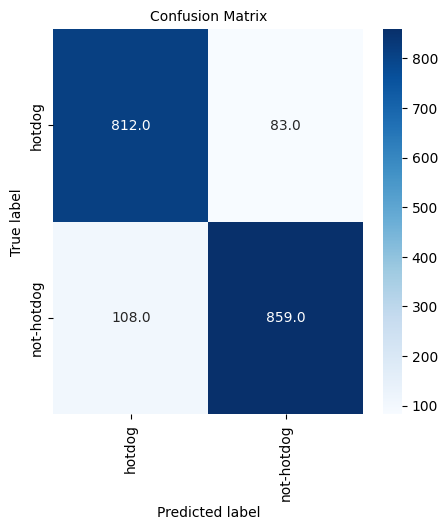

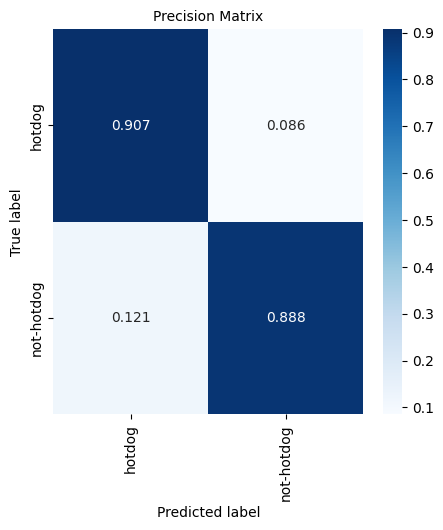

In [5]:
trainer.confusionMatrix(model)